In [2]:
import os, random
from pathlib import Path
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import optuna
from sklearn.calibration import CalibratedClassifierCV
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import (
    roc_auc_score, accuracy_score, precision_score, recall_score, f1_score,
    mean_absolute_error, mean_squared_error, r2_score, median_absolute_error,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from xgboost import XGBClassifier, XGBRegressor

SEED = 42
LOG_EPS = 1e-6
MIN_OBSERVED_TARGETS = 2
LOW_OBS_THRESHOLD = 30

X_cols = ["Construction period", "Typology", "Primary Code", "Hybrid Structure", "Country"]
y_cols = ["Concrete", "Glass", "Steel", "Wood", "Brick"]

def set_global_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)

set_global_seed(SEED)
optuna.logging.set_verbosity(optuna.logging.WARNING)
print("Imports complete.  SEED =", SEED)

# -- Visualisation style constants --
_C1   = "#4C72B0"   # main blue
_C2   = "#DD8452"   # accent orange
_REF  = "#C44E52"   # reference-line red
_GRAY = "#AAAAAA"

plt.rcParams.update({
    "figure.dpi":         110,
    "axes.spines.top":    False,
    "axes.spines.right":  False,
    "axes.grid":          True,
    "grid.alpha":         0.3,
    "font.size":          10,
})

c:\Users\Wanyu Pei\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Imports complete.  SEED = 42


In [3]:
# ==========================================================
# Data Preparation
# ==========================================================

def prepare_data(
    file_path="Integrated_MI_database_add_Singapore.xlsx",
    test_size=0.30,
    val_size=0.50,
    clip_upper_quantile=0.99,
    clip_materials=("Steel", "Glass", "Concrete", "Brick", "Wood"),
    min_observed_targets=MIN_OBSERVED_TARGETS,
    random_state=SEED,
):
    file_path = Path(file_path)
    if not file_path.is_absolute():
        file_path = Path.cwd() / file_path

    df = pd.read_excel(file_path)
    df["Construction period"] = pd.to_numeric(df["Construction period"], errors="coerce")
    df = df.dropna(subset=X_cols).reset_index(drop=True)

    target_mask_df = df[y_cols].notna()
    df = df.loc[target_mask_df.sum(axis=1) >= min_observed_targets].reset_index(drop=True)

    X = df[X_cols].copy()
    y_raw_df = df[y_cols].copy()
    y_mask = y_raw_df.notna().to_numpy(dtype=bool)

    X_train, X_temp, y_train_df, y_temp_df, y_train_mask, y_temp_mask = train_test_split(
        X, y_raw_df, y_mask, test_size=test_size, random_state=random_state
    )
    X_val, X_test, y_val_df, y_test_df, y_val_mask, y_test_mask = train_test_split(
        X_temp, y_temp_df, y_temp_mask, test_size=val_size, random_state=random_state
    )

    for df_ in [X_train, X_val, X_test, y_train_df, y_val_df, y_test_df]:
        df_.reset_index(drop=True, inplace=True)

    y_train_raw = y_train_df.to_numpy(dtype=np.float64).copy()
    y_val_raw   = y_val_df.to_numpy(dtype=np.float64).copy()
    y_test_raw  = y_test_df.to_numpy(dtype=np.float64).copy()

    # Upper-quantile clipping: bounds from training, applied to all splits
    if clip_upper_quantile is not None:
        mat_to_idx = {m: i for i, m in enumerate(y_cols)}
        for mat in clip_materials:
            if mat not in mat_to_idx:
                continue
            idx = mat_to_idx[mat]
            obs_tr = y_train_mask[:, idx]
            if not np.any(obs_tr):
                continue
            ub = np.quantile(y_train_raw[obs_tr, idx], clip_upper_quantile)
            for arr, mask in [(y_train_raw, y_train_mask), (y_val_raw, y_val_mask),
                              (y_test_raw, y_test_mask)]:
                rows = mask[:, idx]
                arr[rows, idx] = np.minimum(arr[rows, idx], ub)

    preprocessor = ColumnTransformer(transformers=[
        ("num", StandardScaler(), ["Construction period"]),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False),
         ["Typology", "Primary Code", "Hybrid Structure", "Country"]),
    ])
    X_train_proc = preprocessor.fit_transform(X_train)
    X_val_proc   = preprocessor.transform(X_val)
    X_test_proc  = preprocessor.transform(X_test)

    return dict(
        X_train_proc=X_train_proc, X_val_proc=X_val_proc, X_test_proc=X_test_proc,
        X_train_raw=X_train,       X_val_raw=X_val,        X_test_raw=X_test,
        y_train_raw=y_train_raw,   y_val_raw=y_val_raw,    y_test_raw=y_test_raw,
        y_train_df=y_train_df,     y_val_df=y_val_df,      y_test_df=y_test_df,
        y_train_mask=y_train_mask, y_val_mask=y_val_mask,  y_test_mask=y_test_mask,
        preprocessor=preprocessor,
        kept_rows=len(df),
        min_observed_targets=min_observed_targets,
    )


In [4]:
set_global_seed(SEED)
data = prepare_data()

print("Data preparation complete.")
print(f"X_train: {data['X_train_proc'].shape}  y_train: {data['y_train_raw'].shape}")
print(f"X_val:   {data['X_val_proc'].shape}  y_val:   {data['y_val_raw'].shape}")
print(f"X_test:  {data['X_test_proc'].shape}  y_test:  {data['y_test_raw'].shape}")
print(f"Rows kept: {data['kept_rows']}  (min observed targets: {data['min_observed_targets']})")


Data preparation complete.
X_train: (1799, 47)  y_train: (1799, 5)
X_val:   (385, 47)  y_val:   (385, 5)
X_test:  (386, 47)  y_test:  (386, 5)
Rows kept: 2570  (min observed targets: 2)


### Data Interpretation

Material intensity columns contain **positive reported values** or **missing values**.
Missing values are **not** interpreted as zero or as confirmed material absence.
They reflect database incompleteness: a survey may not have recorded every material
for every building.

This notebook **estimates reported material intensity patterns from an incomplete
database**. The model supports database querying, gap exploration, and early-stage
estimation — not verification of true physical material stocks.

**Stage 1** (`ObservationModel`) predicts *P(recorded | x)*: probability that the
database contains an intensity value for a given material in a building with
features *x*.

**Stage 2** (`IntensityModel`) estimates the intensity value (kg/m²), conditioned on
the material being recorded, using quantile regression.


In [5]:
# ==========================================================
# Missingness / Observation Rate Summary
# ==========================================================

header = (f"{'Material':<12}  {'n_train':>8}  {'obs%_train':>10}  "
          f"{'n_val':>6}  {'obs%_val':>8}  {'n_test':>7}  {'obs%_test':>9}")
print(header)
print("-" * len(header))

for m, mat in enumerate(y_cols):
    n_tr = int(data['y_train_mask'][:, m].sum())
    n_v  = int(data['y_val_mask'][:, m].sum())
    n_te = int(data['y_test_mask'][:, m].sum())
    r_tr = n_tr / len(data['y_train_mask']) * 100
    r_v  = n_v  / len(data['y_val_mask'])   * 100
    r_te = n_te / len(data['y_test_mask'])  * 100
    print(f"{mat:<12}  {n_tr:>8}  {r_tr:>9.1f}%  "
          f"{n_v:>6}  {r_v:>7.1f}%  {n_te:>7}  {r_te:>8.1f}%")


Material       n_train  obs%_train   n_val  obs%_val   n_test  obs%_test
------------------------------------------------------------------------
Concrete          1385       77.0%     282     73.2%      297      76.9%
Glass              886       49.2%     176     45.7%      193      50.0%
Steel             1638       91.1%     344     89.4%      346      89.6%
Wood              1452       80.7%     316     82.1%      313      81.1%
Brick             1200       66.7%     257     66.8%      277      71.8%


In [6]:
# ==========================================================
# Stage 1 — Observation Model
# ==========================================================
#
# Predicts P(recorded | x) per material.
# Target: material_column.notna()   (NOT material presence/absence)
# Missing != absent; missing = database gap.
#
# One CalibratedClassifierCV(XGBClassifier, method='sigmoid') per material.

class ObservationModel:
    """Per-material XGBoost classifier predicting P(recorded | x)."""

    def __init__(self, n_estimators=300, max_depth=4, learning_rate=0.05,
                 subsample=0.8, colsample_bytree=0.8,
                 reg_alpha=0.0, reg_lambda=1.0, random_state=SEED):
        self.xgb_params = dict(
            n_estimators=n_estimators, max_depth=max_depth,
            learning_rate=learning_rate, subsample=subsample,
            colsample_bytree=colsample_bytree, reg_alpha=reg_alpha,
            reg_lambda=reg_lambda, random_state=random_state,
            objective="binary:logistic", verbosity=0,
        )
        self.models_ = {}
        self.trivial_proba_ = {}

    def fit(self, X, y_observed):
        """Fit one CalibratedClassifierCV per material.

        Parameters
        ----------
        X          : (n, d) preprocessed feature matrix
        y_observed : (n, M) bool  --  True where intensity was recorded
        """
        self.models_ = {}
        self.trivial_proba_ = {}
        for m, material in enumerate(y_cols):
            s = y_observed[:, m].astype(int)
            p = float(s.mean())
            if p == 0.0 or p == 1.0:
                self.trivial_proba_[material] = p
                self.models_[material] = None
            else:
                base = XGBClassifier(**self.xgb_params)
                clf  = CalibratedClassifierCV(base, method="sigmoid", cv=5)
                clf.fit(X, s)
                self.models_[material] = clf
        return self

    def predict_proba(self, X):
        """Return (n, M) array of P(recorded | x) for each material."""
        n = X.shape[0]
        proba = np.zeros((n, len(y_cols)), dtype=np.float64)
        for m, material in enumerate(y_cols):
            clf = self.models_.get(material)
            if clf is None:
                proba[:, m] = self.trivial_proba_.get(material, 0.0)
            else:
                proba[:, m] = clf.predict_proba(X)[:, 1]
        return proba


In [7]:
# ==========================================================
# Stage 2 — Intensity Model
# ==========================================================
#
# Per-material quantile XGBoost trained on observed rows only.
# Log-space transformation: target = log(y + LOG_EPS).
# Quantile alpha = [0.05, 0.50, 0.95] — trained directly by the model.
#
# Prediction intervals are obtained directly from quantile regression
# outputs and do not rely on a Gaussian residual assumption.

class IntensityModel:
    """Per-material quantile XGBoost estimating conditional intensity (kg/m^2)."""

    ALPHAS = [0.05, 0.50, 0.95]

    def __init__(self, n_estimators=300, max_depth=4, learning_rate=0.05,
                 subsample=0.8, colsample_bytree=0.8,
                 reg_alpha=0.0, reg_lambda=1.0, random_state=SEED):
        self.xgb_params = dict(
            n_estimators=n_estimators, max_depth=max_depth,
            learning_rate=learning_rate, subsample=subsample,
            colsample_bytree=colsample_bytree, reg_alpha=reg_alpha,
            reg_lambda=reg_lambda, random_state=random_state,
            verbosity=0,
        )
        self.models_ = {}

    def fit(self, X, y_raw, y_observed):
        """Train one quantile XGBoost per material on observed rows.

        Parameters
        ----------
        X          : (n, d) preprocessed feature matrix
        y_raw      : (n, M) float  --  intensity values (NaN where unobserved)
        y_observed : (n, M) bool   --  True where intensity was recorded
        """
        self.models_ = {}
        for m, material in enumerate(y_cols):
            obs = y_observed[:, m]
            if obs.sum() < 2:
                self.models_[material] = None
                continue
            y_log = np.log(y_raw[obs, m] + LOG_EPS)
            mdl = XGBRegressor(
                objective="reg:quantileerror",
                quantile_alpha=self.ALPHAS,
                **self.xgb_params,
            )
            mdl.fit(X[obs], y_log)
            self.models_[material] = mdl
        return self

    def predict_quantiles(self, X):
        """Return p05/p50/p95 in original (kg/m^2) space per material.

        Intervals are the direct exp-transformed outputs of the quantile
        regression model (quantile_alpha = [0.05, 0.50, 0.95]).
        No Gaussian approximation is used.

        Returns dict: material -> {"p05": array, "p50": array, "p95": array}
        """
        n = X.shape[0]
        result = {}
        for material in y_cols:
            mdl = self.models_.get(material)
            if mdl is None:
                result[material] = {"p05": np.zeros(n), "p50": np.zeros(n), "p95": np.zeros(n)}
                continue
            pq   = mdl.predict(X)      # (n, 3): [log_p05, log_p50, log_p95]
            p_lo = np.maximum(np.exp(pq[:, 0]) - LOG_EPS, 0.0)
            p50  = np.maximum(np.exp(pq[:, 1]) - LOG_EPS, 0.0)
            p_hi = np.maximum(np.exp(pq[:, 2]) - LOG_EPS, 0.0)
            result[material] = {"p05": p_lo, "p50": p50, "p95": p_hi}
        return result


In [8]:
# ==========================================================
# FinalQueryModel — two-stage wrapper
# ==========================================================

class FinalQueryModel:
    """Two-stage database-informed query model.

    Stage 1 (tuned_observation_model): P(recorded | x) per material.
    Stage 2 (tuned_intensity_model):   conditional intensity quantiles (kg/m^2).
      Intervals are fixed at [0.05, 0.50, 0.95] by the trained quantile model.

    query() output per material
    ---------------------------
    p_recorded        float   P(intensity is recorded in the database)
    p05, p50, p95     float   conditional intensity quantiles (kg/m^2)
    expected_reported float   p_recorded * p50  (unconditional expected intensity)
    n_observed_train  int     training rows with this material recorded
    coverage_warning  bool    True if n_observed_train < LOW_OBS_THRESHOLD
    """

    def __init__(self, observation_params=None, intensity_params=None):
        _default = dict(n_estimators=300, max_depth=4, learning_rate=0.05,
                        subsample=0.8, colsample_bytree=0.8,
                        reg_alpha=0.0, reg_lambda=1.0, random_state=SEED)
        self.tuned_observation_model = ObservationModel(**(observation_params or _default))
        self.tuned_intensity_model   = IntensityModel(**(intensity_params   or _default))

    def fit(self, X_proc, y_raw, y_mask):
        y_observed = y_mask   # True = recorded; missing != absent
        self.n_observed_train_ = {
            mat: int(y_observed[:, m].sum()) for m, mat in enumerate(y_cols)
        }
        self.tuned_observation_model.fit(X_proc, y_observed)
        self.tuned_intensity_model.fit(X_proc, y_raw, y_observed)
        return self

    def query(self, X_proc):
        """Query the model for one or more buildings.

        Parameters
        ----------
        X_proc : (n, d) preprocessed feature matrix

        Returns
        -------
        dict: material -> {p_recorded, p05, p50, p95, expected_reported,
                           n_observed_train, coverage_warning}
        """
        p_recorded = self.tuned_observation_model.predict_proba(X_proc)
        intervals  = self.tuned_intensity_model.predict_quantiles(X_proc)
        result = {}
        for m, mat in enumerate(y_cols):
            n_obs = self.n_observed_train_.get(mat, 0)
            result[mat] = {
                "p_recorded":        p_recorded[:, m],
                "p05":               intervals[mat]["p05"],
                "p50":               intervals[mat]["p50"],
                "p95":               intervals[mat]["p95"],
                "expected_reported": p_recorded[:, m] * intervals[mat]["p50"],
                "n_observed_train":  n_obs,
                "coverage_warning":  n_obs < LOW_OBS_THRESHOLD,
            }
        return result


In [9]:
# ==========================================================
# Hyperparameter Tuning (Optuna)
# Uses training set to fit, validation set to evaluate.
# Test set is untouched until final evaluation.
# ==========================================================

N_TRIALS = 40  # trials per stage

# ── Stage 1: Observation Model ────────────────────────────────────────────────
def _obs_objective(trial):
    params = dict(
        n_estimators     = trial.suggest_int(  "n_estimators",     100, 500),
        max_depth        = trial.suggest_int(  "max_depth",          3,   6),
        learning_rate    = trial.suggest_float("learning_rate",   0.01, 0.2, log=True),
        subsample        = trial.suggest_float("subsample",        0.6, 1.0),
        colsample_bytree = trial.suggest_float("colsample_bytree", 0.6, 1.0),
        reg_alpha        = trial.suggest_float("reg_alpha",        0.0, 2.0),
        reg_lambda       = trial.suggest_float("reg_lambda",       0.5, 5.0),
        random_state     = SEED,
    )
    m = ObservationModel(**params)
    m.fit(data["X_train_proc"], data["y_train_mask"])
    p = m.predict_proba(data["X_val_proc"])
    aucs = [
        roc_auc_score(data["y_val_mask"][:, i].astype(int), p[:, i])
        for i in range(len(y_cols))
        if 0 < data["y_val_mask"][:, i].sum() < len(data["y_val_mask"])
    ]
    return -np.mean(aucs) if aucs else 0.0

obs_study = optuna.create_study(direction="minimize",
                                sampler=optuna.samplers.TPESampler(seed=SEED))
obs_study.optimize(_obs_objective, n_trials=N_TRIALS, show_progress_bar=True)
best_observation_params = {**obs_study.best_params, "random_state": SEED}
print(f"Stage 1 best  mean AUC = {-obs_study.best_value:.4f}")
print("best_observation_params:", best_observation_params)

# ── Stage 2: Intensity Model ──────────────────────────────────────────────────
def _int_objective(trial):
    params = dict(
        n_estimators     = trial.suggest_int(  "n_estimators",     100, 500),
        max_depth        = trial.suggest_int(  "max_depth",          3,   6),
        learning_rate    = trial.suggest_float("learning_rate",   0.01, 0.2, log=True),
        subsample        = trial.suggest_float("subsample",        0.6, 1.0),
        colsample_bytree = trial.suggest_float("colsample_bytree", 0.6, 1.0),
        reg_alpha        = trial.suggest_float("reg_alpha",        0.0, 2.0),
        reg_lambda       = trial.suggest_float("reg_lambda",       0.5, 5.0),
        random_state     = SEED,
    )
    m = IntensityModel(**params)
    m.fit(data["X_train_proc"], data["y_train_raw"], data["y_train_mask"])
    ivs = m.predict_quantiles(data["X_val_proc"])
    maes = [
        mean_absolute_error(data["y_val_raw"][data["y_val_mask"][:, i], i],
                            ivs[mat]["p50"][data["y_val_mask"][:, i]])
        for i, mat in enumerate(y_cols)
        if data["y_val_mask"][:, i].sum() >= 2
    ]
    return np.mean(maes) if maes else 0.0

int_study = optuna.create_study(direction="minimize",
                                sampler=optuna.samplers.TPESampler(seed=SEED))
int_study.optimize(_int_objective, n_trials=N_TRIALS, show_progress_bar=True)
best_intensity_params = {**int_study.best_params, "random_state": SEED}
print(f"\nStage 2 best  mean MAE = {int_study.best_value:.4f}")
print("best_intensity_params:", best_intensity_params)


Best trial: 11. Best value: -0.958004: 100%|██████████| 40/40 [01:40<00:00,  2.50s/it]


Stage 1 best  mean AUC = 0.9580
best_observation_params: {'n_estimators': 303, 'max_depth': 5, 'learning_rate': 0.19854668872060813, 'subsample': 0.9974940948490247, 'colsample_bytree': 0.6036910676177805, 'reg_alpha': 0.8299823034272843, 'reg_lambda': 0.6285362775933057, 'random_state': 42}


Best trial: 34. Best value: 129.047: 100%|██████████| 40/40 [01:13<00:00,  1.83s/it]


Stage 2 best  mean MAE = 129.0469
best_intensity_params: {'n_estimators': 306, 'max_depth': 5, 'learning_rate': 0.08120093309861091, 'subsample': 0.7469731453090837, 'colsample_bytree': 0.7992463678769326, 'reg_alpha': 1.3090490233445204, 'reg_lambda': 1.694872757312384, 'random_state': 42}


In [10]:
# ==========================================================
# Train Final Model with Tuned Hyperparameters
# ==========================================================

set_global_seed(SEED)
final_query_model = FinalQueryModel(
    observation_params=best_observation_params,
    intensity_params=best_intensity_params,
)
final_query_model.fit(
    data["X_train_proc"],
    data["y_train_raw"],
    data["y_train_mask"],
)

# Expose components for evaluation
tuned_observation_model = final_query_model.tuned_observation_model
tuned_intensity_model   = final_query_model.tuned_intensity_model

print("Final model trained.")
for mat, n in final_query_model.n_observed_train_.items():
    warn = "  *** low-data warning" if n < LOW_OBS_THRESHOLD else ""
    print(f"  {mat:<10}  {n:>4} training observations{warn}")


Final model trained.
  Concrete    1385 training observations
  Glass        886 training observations
  Steel       1638 training observations
  Wood        1452 training observations
  Brick       1200 training observations


In [11]:
# ==========================================================
# Stage 1 Evaluation — Recording Probability Model
# Metrics: AUC-ROC, Accuracy, Precision, Recall, F1 (threshold 0.5)
# Evaluated on the held-out test set.
# ==========================================================

p_rec_test = tuned_observation_model.predict_proba(data["X_test_proc"])
y_test_obs  = data["y_test_mask"]

rows = []
for m, mat in enumerate(y_cols):
    y_true = y_test_obs[:, m].astype(int)
    y_prob = p_rec_test[:, m]
    y_pred = (y_prob > 0.5).astype(int)
    if y_true.sum() == 0 or y_true.sum() == len(y_true):
        rows.append({"Material": mat, "AUC": "—", "Accuracy": "—",
                     "Precision": "—", "Recall": "—", "F1": "—",
                     "n_pos": int(y_true.sum()), "n_neg": int((1 - y_true).sum())})
        continue
    rows.append({
        "Material":  mat,
        "AUC":       round(roc_auc_score(y_true, y_prob), 3),
        "Accuracy":  round(accuracy_score(y_true, y_pred), 3),
        "Precision": round(precision_score(y_true, y_pred, zero_division=0), 3),
        "Recall":    round(recall_score(y_true, y_pred), 3),
        "F1":        round(f1_score(y_true, y_pred, zero_division=0), 3),
        "n_pos":     int(y_true.sum()),
        "n_neg":     int((1 - y_true).sum()),
    })

print("Stage 1 — Recording probability model  (test set)")
print(pd.DataFrame(rows).to_string(index=False))


Stage 1 — Recording probability model  (test set)
Material   AUC  Accuracy  Precision  Recall    F1  n_pos  n_neg
Concrete 0.972     0.930      0.950   0.960 0.955    297     89
   Glass 0.964     0.909      0.939   0.876 0.906    193    193
   Steel 0.980     0.956      0.969   0.983 0.976    346     40
    Wood 0.951     0.927      0.952   0.958 0.955    313     73
   Brick 0.943     0.896      0.937   0.917 0.927    277    109


In [12]:
# ==========================================================
# Stage 2 Evaluation — Conditional Intensity: Point Estimates
# Metrics: MAE, RMSE, R2, Median AE  (observed rows only)
# Evaluated on the held-out test set.
# ==========================================================

intervals_test = tuned_intensity_model.predict_quantiles(data["X_test_proc"])

print("Stage 2 — Conditional intensity model  (test set, observed rows only)")
print(f"{'Material':<12}  {'n_obs':>6}  {'MAE':>8}  {'RMSE':>8}  {'R2':>8}  {'MedianAE':>9}")
print("-" * 60)

for m, mat in enumerate(y_cols):
    obs = data["y_test_mask"][:, m]
    if obs.sum() < 2:
        print(f"{mat:<12}  {'—':>6}")
        continue
    y_true = data["y_test_raw"][obs, m]
    y_hat  = intervals_test[mat]["p50"][obs]
    mae    = mean_absolute_error(y_true, y_hat)
    rmse   = np.sqrt(mean_squared_error(y_true, y_hat))
    r2     = r2_score(y_true, y_hat)
    medae  = median_absolute_error(y_true, y_hat)
    print(f"{mat:<12}  {int(obs.sum()):>6}  {mae:>8.2f}  {rmse:>8.2f}  {r2:>8.3f}  {medae:>9.2f}")


Stage 2 — Conditional intensity model  (test set, observed rows only)
Material       n_obs       MAE      RMSE        R2   MedianAE
------------------------------------------------------------
Concrete         297    460.11    742.63     0.264     294.52
Glass            193      1.18      1.77     0.369       0.77
Steel            346     19.19     46.51     0.266       7.84
Wood             313      9.35     18.69     0.566       4.02
Brick            277    210.46    295.85     0.406     150.31


In [13]:
# ==========================================================
# Stage 2 Evaluation — Prediction Interval Coverage and Width
# Nominal 90% interval (alpha = 0.10)
# Evaluated on the held-out test set.
# ==========================================================

print("Stage 2 — 90% prediction interval  (test set, observed rows only)")
print(f"{'Material':<12}  {'n_obs':>6}  {'Coverage':>9}  {'Mean Width':>11}  {'Median Width':>13}")
print("-" * 58)

for m, mat in enumerate(y_cols):
    obs = data["y_test_mask"][:, m]
    if obs.sum() < 2:
        print(f"{mat:<12}  {'—':>6}")
        continue
    y_true = data["y_test_raw"][obs, m]
    p05    = intervals_test[mat]["p05"][obs]
    p95    = intervals_test[mat]["p95"][obs]
    cov    = float(((y_true >= p05) & (y_true <= p95)).mean())
    w      = p95 - p05
    print(f"{mat:<12}  {int(obs.sum()):>6}  {cov:>9.3f}  {w.mean():>11.2f}  {np.median(w):>13.2f}")


Stage 2 — 90% prediction interval  (test set, observed rows only)
Material       n_obs   Coverage   Mean Width   Median Width
----------------------------------------------------------
Concrete         297      0.832      1927.80        1814.93
Glass            193      0.819         4.34           4.19
Steel            346      0.867        86.12          52.66
Wood             313      0.834        37.07          38.17
Brick            277      0.852       864.15         792.77


In [14]:
# ==========================================================
# Baseline Comparison — Stage 2 p50 vs naive baselines
# Baselines: training-median, Ridge (log-space), RandomForest
# Evaluated on the held-out test set.
# ==========================================================

print("Baseline comparison  (test set, observed rows only)")
print(f"{'Material':<12}  {'Stage2 MAE':>12}  {'Median MAE':>12}  {'Ridge MAE':>10}  {'RF MAE':>8}")
print("-" * 62)

for m, mat in enumerate(y_cols):
    obs_tr = data["y_train_mask"][:, m]
    obs_te = data["y_test_mask"][:, m]
    if obs_tr.sum() < 2 or obs_te.sum() < 2:
        print(f"{mat:<12}  {'—':>12}")
        continue

    X_tr = data["X_train_proc"][obs_tr]
    y_tr = data["y_train_raw"][obs_tr, m]
    X_te = data["X_test_proc"][obs_te]
    y_te = data["y_test_raw"][obs_te, m]

    mae_s2  = mean_absolute_error(y_te, intervals_test[mat]["p50"][obs_te])
    mae_med = mean_absolute_error(y_te, np.full(obs_te.sum(), np.median(y_tr)))

    ridge = Ridge(alpha=1.0)
    ridge.fit(X_tr, np.log(y_tr + LOG_EPS))
    mae_ridge = mean_absolute_error(y_te, np.maximum(np.exp(ridge.predict(X_te)) - LOG_EPS, 0.0))

    rf = RandomForestRegressor(n_estimators=100, random_state=SEED, n_jobs=-1)
    rf.fit(X_tr, y_tr)
    mae_rf = mean_absolute_error(y_te, rf.predict(X_te))

    print(f"{mat:<12}  {mae_s2:>12.2f}  {mae_med:>12.2f}  {mae_ridge:>10.2f}  {mae_rf:>8.2f}")


Baseline comparison  (test set, observed rows only)
Material        Stage2 MAE    Median MAE   Ridge MAE    RF MAE
--------------------------------------------------------------
Concrete            460.11        662.18      620.58    478.86
Glass                 1.18          1.42        1.27      1.20
Steel                19.19         30.40       25.29     20.39
Wood                  9.35         17.62       14.11     10.53
Brick               210.46        301.84      268.59    223.31


In [15]:
# ==========================================================
# Final Summary Table — Test Set
# ==========================================================

print("Final Summary — Test Set")
hdr = (f"{'Material':<12}  {'n_obs_train':>12}  {'AUC':>6}  "
       f"{'MAE':>8}  {'RMSE':>8}  {'R2':>6}  {'Cov90':>7}  {'MeanWidth':>10}")
print(hdr)
print("-" * len(hdr))

summary_rows = []
for m, mat in enumerate(y_cols):
    n_obs_train = final_query_model.n_observed_train_.get(mat, 0)

    y_cls = data["y_test_mask"][:, m].astype(int)
    y_prb = p_rec_test[:, m]
    auc = (round(roc_auc_score(y_cls, y_prb), 3)
           if 0 < y_cls.sum() < len(y_cls) else float("nan"))

    obs_te = data["y_test_mask"][:, m]
    if obs_te.sum() < 2:
        mae = rmse = r2 = cov = width = float("nan")
    else:
        y_te   = data["y_test_raw"][obs_te, m]
        p50_te = intervals_test[mat]["p50"][obs_te]
        p05_te = intervals_test[mat]["p05"][obs_te]
        p95_te = intervals_test[mat]["p95"][obs_te]
        mae    = round(mean_absolute_error(y_te, p50_te), 2)
        rmse   = round(np.sqrt(mean_squared_error(y_te, p50_te)), 2)
        r2     = round(r2_score(y_te, p50_te), 3)
        cov    = round(float(((y_te >= p05_te) & (y_te <= p95_te)).mean()), 3)
        width  = round(float((p95_te - p05_te).mean()), 2)

    summary_rows.append({"Material": mat, "n_obs_train": n_obs_train, "AUC": auc,
                          "MAE": mae, "RMSE": rmse, "R2": r2, "Cov90": cov, "MeanWidth": width})
    print(f"{mat:<12}  {n_obs_train:>12}  {str(auc):>6}  "
          f"{str(mae):>8}  {str(rmse):>8}  {str(r2):>6}  {str(cov):>7}  {str(width):>10}")

summary_df = pd.DataFrame(summary_rows)


def _val(mat, col):
    """Extract a numeric metric from summary_df; return NaN if unavailable."""
    v = summary_df.loc[summary_df["Material"] == mat, col].iat[0]
    return float(v) if not pd.isna(v) else float("nan")

Final Summary — Test Set
Material       n_obs_train     AUC       MAE      RMSE      R2    Cov90   MeanWidth
-----------------------------------------------------------------------------------
Concrete              1385   0.972    460.11    742.63   0.264    0.832      1927.8
Glass                  886   0.964      1.18      1.77   0.369    0.819        4.34
Steel                 1638    0.98     19.19     46.51   0.266    0.867       86.12
Wood                  1452   0.951      9.35     18.69   0.566    0.834       37.07
Brick                 1200   0.943    210.46    295.85   0.406    0.852      864.15


---

## Model Result Visualisations

The six figures below summarise the final tuned model evaluated on the held-out
test set. No training or validation data appear here. All figures use
`tuned_observation_model` and `tuned_intensity_model` from `final_query_model`.


### Figure 1 — Database coverage: observed records per material

Shows how many buildings have a recorded (non-missing) intensity value for each
material across all rows in the dataset. The percentage label is the fraction of
all buildings with a recorded value. Materials with lower coverage carry higher
recording uncertainty in Stage 1.


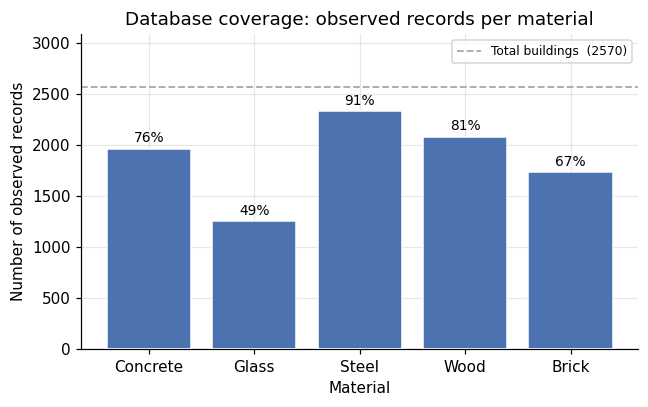

In [16]:
# ==========================================================
# Figure 1 — Database coverage
# ==========================================================

y_all_mask = np.vstack([data["y_train_mask"], data["y_val_mask"], data["y_test_mask"]])
n_total    = len(y_all_mask)
n_obs      = y_all_mask.sum(axis=0)
pct        = n_obs / n_total * 100

fig, ax = plt.subplots(figsize=(6, 3.8))
bars = ax.bar(y_cols, n_obs, color=_C1, edgecolor="white", zorder=3)
ax.axhline(n_total, color=_GRAY, lw=1.2, ls="--",
           label=f"Total buildings  ({n_total})", zorder=2)
for bar, p in zip(bars, pct):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + n_total * 0.012,
            f"{p:.0f}%", ha="center", va="bottom", fontsize=9)
ax.set_xlabel("Material")
ax.set_ylabel("Number of observed records")
ax.set_title("Database coverage: observed records per material")
ax.set_ylim(0, n_total * 1.20)
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()


### Figure 2 — Observation model performance by material

AUC-ROC of the Stage 1 observation model on the test set, per material. A higher
AUC indicates the model better distinguishes buildings with a recorded value from
those without. The dashed red line marks the random-classifier baseline (AUC = 0.5).


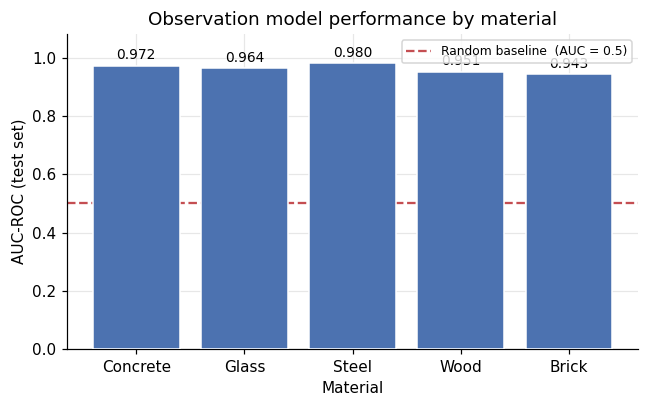

In [17]:
# ==========================================================
# Figure 2 — Observation model performance (AUC)
# ==========================================================

aucs   = [_val(mat, "AUC") for mat in y_cols]
colors = [_C1 if not pd.isna(v) else _GRAY for v in aucs]
vals   = [v if not pd.isna(v) else 0.0 for v in aucs]

fig, ax = plt.subplots(figsize=(6, 3.8))
bars = ax.bar(y_cols, vals, color=colors, edgecolor="white", zorder=3)
ax.axhline(0.5, color=_REF, lw=1.5, ls="--",
           label="Random baseline  (AUC = 0.5)", zorder=2)
for bar, v in zip(bars, aucs):
    if not pd.isna(v):
        ax.text(bar.get_x() + bar.get_width() / 2, v + 0.012,
                f"{v:.3f}", ha="center", va="bottom", fontsize=9)
ax.set_ylim(0, 1.08)
ax.set_xlabel("Material")
ax.set_ylabel("AUC-ROC (test set)")
ax.set_title("Observation model performance by material")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()


### Figure 3 — Conditional reported-intensity model error by material

Mean absolute error (MAE, kg/m²) of the Stage 2 model's median prediction (p50)
against observed reported intensity values on the test set. Only buildings where
the material was recorded are included. Lower MAE indicates more accurate
conditional intensity estimates.


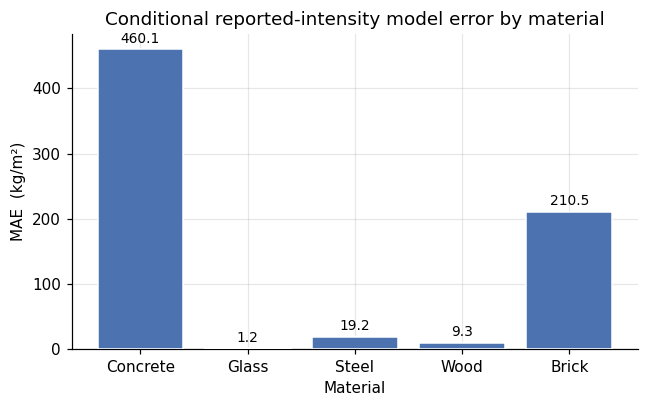

In [18]:
# ==========================================================
# Figure 3 — Conditional intensity model error (MAE)
# ==========================================================

maes   = [_val(mat, "MAE") for mat in y_cols]
colors = [_C1 if not pd.isna(v) else _GRAY for v in maes]
vals   = [v if not pd.isna(v) else 0.0 for v in maes]

fig, ax = plt.subplots(figsize=(6, 3.8))
bars = ax.bar(y_cols, vals, color=colors, edgecolor="white", zorder=3)
for bar, v in zip(bars, maes):
    if not pd.isna(v) and v > 0:
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + max(vals) * 0.012,
                f"{v:.1f}", ha="center", va="bottom", fontsize=9)
ax.set_xlabel("Material")
ax.set_ylabel("MAE  (kg/m²)")
ax.set_title("Conditional reported-intensity model error by material")
plt.tight_layout()
plt.show()


### Figure 4 — Observed vs predicted reported intensity (test set)

Each panel shows observed reported intensity (x-axis) against the model's
median prediction, p50, (y-axis) for buildings where that material was recorded.
Points near the 1:1 reference line indicate accurate predictions.
Log scale is applied where the 5th–95th percentile range spans more than
one order of magnitude.


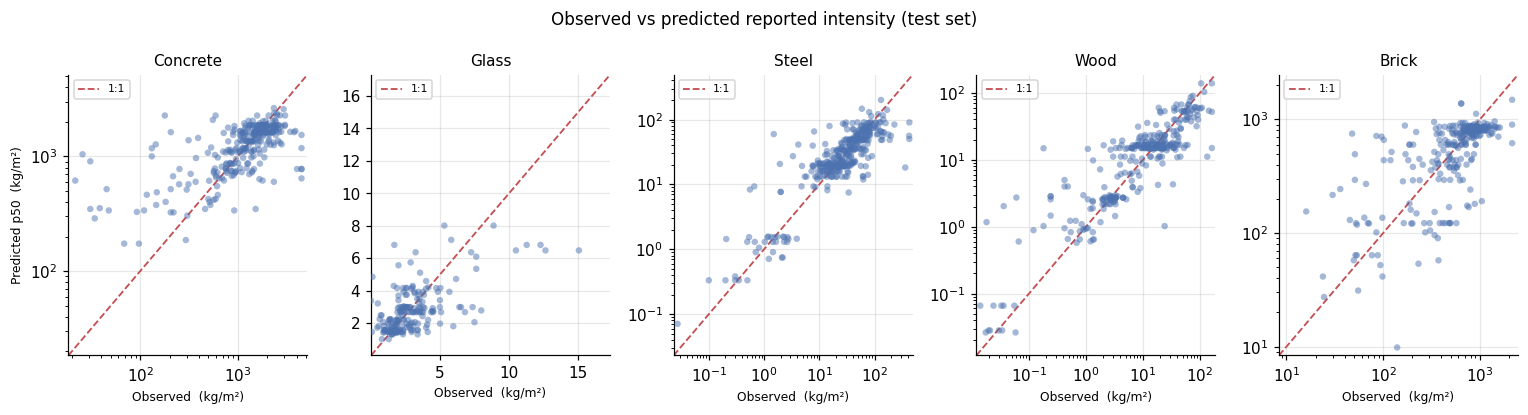

In [19]:
# ==========================================================
# Figure 4 — Observed vs predicted reported intensity
# ==========================================================

fig, axes = plt.subplots(1, len(y_cols), figsize=(14, 3.8))

for ax, m in zip(axes, range(len(y_cols))):
    mat  = y_cols[m]
    obs  = data["y_test_mask"][:, m]
    if obs.sum() < 2:
        ax.text(0.5, 0.5, "insufficient\ndata", transform=ax.transAxes,
                ha="center", va="center", color=_GRAY)
        ax.set_title(mat, fontsize=10)
        continue

    y_true = data["y_test_raw"][obs, m]
    y_pred = intervals_test[mat]["p50"][obs]

    use_log = (len(y_true) > 4 and
               np.percentile(y_true, 95) / (np.percentile(y_true, 5) + 1e-6) > 10)

    ax.scatter(y_true, y_pred, s=18, alpha=0.5, color=_C1, edgecolors="none", zorder=3)

    lo = min(y_true.min(), y_pred.min()) * 0.85
    hi = max(y_true.max(), y_pred.max()) * 1.15
    if use_log:
        lo = max(lo, 1e-2)
    ax.plot([lo, hi], [lo, hi], color=_REF, lw=1.2, ls="--", label="1:1", zorder=2)

    if use_log:
        ax.set_xscale("log")
        ax.set_yscale("log")
    ax.set_xlim(lo, hi)
    ax.set_ylim(lo, hi)

    ax.set_title(mat, fontsize=10)
    ax.set_xlabel("Observed  (kg/m²)", fontsize=8)
    if m == 0:
        ax.set_ylabel("Predicted p50  (kg/m²)", fontsize=8)
    ax.legend(fontsize=7, loc="upper left")

fig.suptitle("Observed vs predicted reported intensity (test set)", fontsize=11)
plt.tight_layout()
plt.show()


### Figure 5 — Empirical coverage of 90% prediction intervals

Each bar shows the fraction of test-set observations that fall within the model's
predicted 90% interval (p05–p95) for that material. Bars close to the dashed
reference line at 0.90 indicate well-calibrated intervals. Over-coverage (bar > 0.90)
suggests the intervals are too wide; under-coverage suggests they are too narrow.


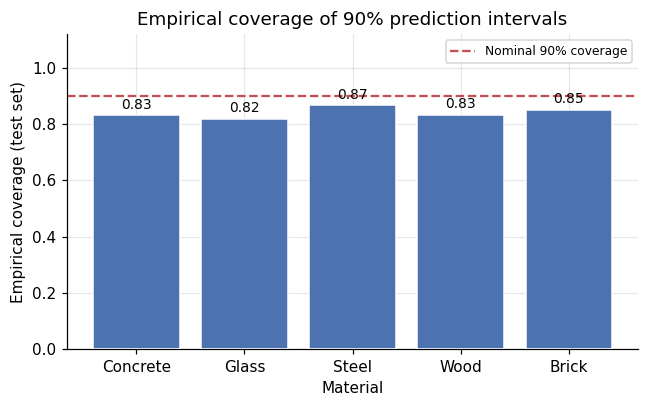

In [20]:
# ==========================================================
# Figure 5 — Empirical interval coverage
# ==========================================================

covs   = [_val(mat, "Cov90") for mat in y_cols]
colors = [(_C1 if abs(v - 0.9) <= 0.1 else _C2) if not pd.isna(v) else _GRAY
          for v in covs]
vals   = [v if not pd.isna(v) else 0.0 for v in covs]

fig, ax = plt.subplots(figsize=(6, 3.8))
bars = ax.bar(y_cols, vals, color=colors, edgecolor="white", zorder=3)
ax.axhline(0.90, color=_REF, lw=1.5, ls="--",
           label="Nominal 90% coverage", zorder=2)
for bar, v in zip(bars, covs):
    if not pd.isna(v):
        ax.text(bar.get_x() + bar.get_width() / 2, v + 0.012,
                f"{v:.2f}", ha="center", va="bottom", fontsize=9)
ax.set_ylim(0, 1.12)
ax.set_xlabel("Material")
ax.set_ylabel("Empirical coverage (test set)")
ax.set_title("Empirical coverage of 90% prediction intervals")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()


### Figure 6 — Example query output for a single building

This panel illustrates how to interpret `FinalQueryModel.query()` output for one
building from the test set. The **left panel** shows the recording probability
for each material — the estimated chance that the database contains a value for this
building type. The **right panel** shows the conditional reported intensity (bar = p50)
with the 90% prediction interval (error bars); orange dots show the expected reported
intensity, which is the recording probability multiplied by the conditional median.


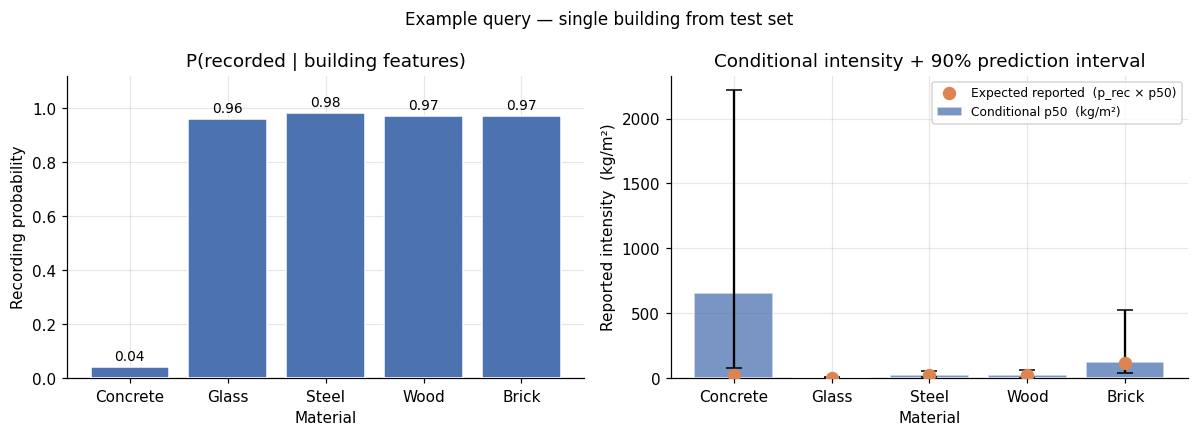


Example building features:
  Construction period: 1999
  Typology: R-UNK
  Primary Code: S
  Hybrid Structure: 1
  Country: China


In [21]:
# ==========================================================
# Figure 6 — Example query output
# ==========================================================

# Pick first test row where at least 3 materials are recorded
example_idx = next(
    (i for i in range(len(data["X_test_proc"]))
     if data["y_test_mask"][i].sum() >= 3),
    0,
)
X_ex   = data["X_test_proc"][example_idx : example_idx + 1]
result = final_query_model.query(X_ex)

p_rec   = [float(result[mat]["p_recorded"][0])       for mat in y_cols]
p50     = [float(result[mat]["p50"][0])               for mat in y_cols]
p05     = [float(result[mat]["p05"][0])               for mat in y_cols]
p95     = [float(result[mat]["p95"][0])               for mat in y_cols]
exp_rep = [float(result[mat]["expected_reported"][0]) for mat in y_cols]
x       = np.arange(len(y_cols))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

# -- Left: recording probability --
ax1.bar(y_cols, p_rec, color=_C1, edgecolor="white", zorder=3)
for i, v in enumerate(p_rec):
    ax1.text(i, v + 0.025, f"{v:.2f}", ha="center", fontsize=9)
ax1.set_ylim(0, 1.12)
ax1.set_xlabel("Material")
ax1.set_ylabel("Recording probability")
ax1.set_title("P(recorded | building features)")

# -- Right: conditional intensity + PI --
err_lo = [max(p50[i] - p05[i], 0.0) for i in range(len(y_cols))]
err_hi = [max(p95[i] - p50[i], 0.0) for i in range(len(y_cols))]
ax2.bar(x, p50, color=_C1, alpha=0.75, edgecolor="white",
        label="Conditional p50  (kg/m²)", zorder=3)
ax2.errorbar(x, p50, yerr=[err_lo, err_hi],
             fmt="none", color="black", capsize=5, lw=1.5, zorder=4)
ax2.scatter(x, exp_rep, color=_C2, zorder=5, s=60,
            label="Expected reported  (p_rec × p50)")
ax2.set_xticks(x)
ax2.set_xticklabels(y_cols)
ax2.set_xlabel("Material")
ax2.set_ylabel("Reported intensity  (kg/m²)")
ax2.set_title("Conditional intensity + 90% prediction interval")
ax2.legend(fontsize=8)

fig.suptitle("Example query — single building from test set", fontsize=11)
plt.tight_layout()
plt.show()

# Print building context
bldg = data["X_test_raw"].iloc[example_idx]
print("\nExample building features:")
for col in X_cols:
    print(f"  {col}: {bldg[col]}")


In [25]:
# ==========================================================
# Save All Application-Required Files
# ==========================================================
#
# Files saved
# -----------
# final_query_model.joblib   -- trained two-stage model (Stage 1 + Stage 2)
# preprocessor.joblib        -- sklearn ColumnTransformer for raw-feature inference
# best_observation_params.json -- Stage 1 Optuna-tuned hyperparameters
# best_intensity_params.json   -- Stage 2 Optuna-tuned hyperparameters
# evaluation_summary.csv     -- per-material test-set metrics
# model_info.json            -- column names, thresholds, split sizes

import json as _json

# 1. Trained model
joblib.dump(final_query_model, "model.joblib")
print("Saved: model.joblib")

# 2. Preprocessor  (required to transform raw X before calling query())
joblib.dump(data["preprocessor"], "preprocessor.joblib")
print("Saved: preprocessor.joblib")

# 3. Tuned hyperparameters
with open("best_observation_params.json", "w") as _f:
    _json.dump(best_observation_params, _f, indent=2)
print("Saved: best_observation_params.json")

with open("best_intensity_params.json", "w") as _f:
    _json.dump(best_intensity_params, _f, indent=2)
print("Saved: best_intensity_params.json")

# 4. Evaluation results
summary_df.to_csv("evaluation_summary.csv", index=False)
print("Saved: evaluation_summary.csv")

# 5. Model metadata  (column names, constants, data-split sizes)
_model_info = {
    "X_cols":              X_cols,
    "y_cols":              y_cols,
    "SEED":                SEED,
    "LOW_OBS_THRESHOLD":   LOW_OBS_THRESHOLD,
    "n_observed_train":    final_query_model.n_observed_train_,
    "data_split": {
        "n_train": int(len(data["X_train_proc"])),
        "n_val":   int(len(data["X_val_proc"])),
        "n_test":  int(len(data["X_test_proc"])),
    },
}
with open("model_info.json", "w") as _f:
    _json.dump(_model_info, _f, indent=2)
print("Saved: model_info.json")

print("\nAll application files saved.")
print("To run inference on new data:")
print("  model = joblib.load('final_query_model.joblib')")
print("  pre   = joblib.load('preprocessor.joblib')")
print("  X_proc = pre.transform(X_raw[X_cols])")
print("  result = model.query(X_proc)")

Saved: model.joblib
Saved: preprocessor.joblib
Saved: best_observation_params.json
Saved: best_intensity_params.json
Saved: evaluation_summary.csv
Saved: model_info.json

All application files saved.
To run inference on new data:
  model = joblib.load('final_query_model.joblib')
  pre   = joblib.load('preprocessor.joblib')
  X_proc = pre.transform(X_raw[X_cols])
  result = model.query(X_proc)
